# 01 - Baselines: centroide ponderado y KNN-DtC

Reproducimos sobre el dataset de Matey-Sanz et al. los dos *baselines* contra los que se compara CAE-CNNLoc 2D-Temporal:

1. **Centroide ponderado**: lateración con pesos $1/d^2$ sobre los cuatro APs (`lib.methods.centroid`).
2. **KNN con distancia DtC** (offset-normalized euclidean), variantes con $k\in\{1,3,5,10\}$ entrenadas en cada subset y evaluadas en los otros tres (`lib.methods.fingerprinting` + `euclidean_rtt`).

Se evalúan tres regímenes de agregación temporal: muestra individual (`raw`), mediana en ventana de 1 s y mediana en ventana de 5 s.

Los resultados se guardan en `results/01_baselines_*.csv` y `results/01_baselines_*.pdf` para usarlos después en el notebook 03.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
print('Project root:', ROOT)
print('Results dir :', RESULTS)

Project root: C:\TFG\codigo
Results dir : C:\TFG\codigo\results


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cnnloc_rtt.data import load_full_dataset, build_classic_subsets

ds = load_full_dataset()
print('APs:', len(ds.aps), '| Reference points:', len(ds.ref_locations))

APs: 4 | Reference points: 20


## Bridge al paquete original

Importamos las implementaciones validadas de `lib/methods.py` para no reinventar la rueda. Convertimos las distancias a **metros** para uniformizar unidades con el resto del trabajo.

In [3]:
from lib.methods import centroid, fingerprinting, euclidean_rtt
from lib.model import Device, MeasuringType
from cnnloc_rtt.data import DISTANCE_MM_TO_M

WINDOWS = [None, '1S', '5S']  # raw, 1 s median window, 5 s median window
WINDOW_LABEL = {None: 'raw', '1S': '1s', '5S': '5s'}

In [4]:
def to_long_df(method, train_set_key, results_df, window_label):
    """Standardise the dataframe schema to the long format used in the rest of the project.

    The original lib/methods.py returns errors and estimated coordinates in
    metres already (the AP and reference-point coordinates are read in
    metres from the CSV files), so no unit conversion is applied here.
    """
    df = results_df.reset_index(drop=True).copy()
    df['method'] = method
    df['train_set'] = str(train_set_key) if train_set_key is not None else 'self'
    df['window'] = window_label
    return df

## 1. Centroide ponderado

El centroide ponderado se evalúa sobre cada subset independientemente: no requiere entrenamiento.

In [5]:
centroid_rows = []
for w in WINDOWS:
    classic_sets = build_classic_subsets(ds, window_size=w)
    classic_sets_native = {k: tuple(v) for k, v in classic_sets.items()}
    for set_key, (X, y) in classic_sets_native.items():
        device, mt = set_key.split('#')
        device_enum = Device.POCO if device == 'POCO' else Device.SAMSUNG
        mt_enum = MeasuringType.STANDING if mt == 'STANDING' else MeasuringType.TRIPOD
        df = centroid(classic_sets_native, ds.aps, ds.ref_locations, device_enum, mt_enum)
        centroid_rows.append(to_long_df('centroide', None, df, WINDOW_LABEL[w]))
        print(f'  centroide | {set_key:<20s} | window={WINDOW_LABEL[w]:<3s} | mean_err={df["error"].mean():.3f} m')

df_centroid = pd.concat(centroid_rows, ignore_index=True)
df_centroid.to_csv(RESULTS / '01_baselines_centroid.csv', index=False)
print(f'\nSaved {len(df_centroid)} rows to results/01_baselines_centroid.csv')

C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


  centroide | POCO#STANDING        | window=raw | mean_err=1.908 m
  centroide | POCO#TRIPOD          | window=raw | mean_err=1.807 m


  centroide | SAMSUNG#STANDING     | window=raw | mean_err=1.747 m
  centroide | SAMSUNG#TRIPOD       | window=raw | mean_err=1.739 m


C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp", "AP MAC Address", "Distance (mm)", "Std Dev (mm)"]].groupby([pd.Grouper(key="Timestamp", freq=freq), "AP MAC Address"]).median()
C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp", "AP MAC Address", "Distance (mm)", "Std Dev (mm)"]].groupby([pd.Grouper(key="Timestamp", freq=freq), "AP MAC Address"]).median()
C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxe

C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp", "AP MAC Address", "Distance (mm)", "Std Dev (mm)"]].groupby([pd.Grouper(key="Timestamp", freq=freq), "AP MAC Address"]).median()
C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp",

...

C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp", "AP MAC Address", "Distance (mm)", "Std Dev (mm)"]].groupby([pd.Grouper(key="Timestamp", freq=freq), "AP MAC Address"]).median()
C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp",

C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp", "AP MAC Address", "Distance (mm)", "Std Dev (mm)"]].groupby([pd.Grouper(key="Timestamp", freq=freq), "AP MAC Address"]).median()
C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp",

C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp", "AP MAC Address", "Distance (mm)", "Std Dev (mm)"]].groupby([pd.Grouper(key="Timestamp", freq=freq), "AP MAC Address"]).median()
C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\TFG\Comparative_Analysis_Android_RTT_main\lib\data_processing.py:32: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  grouped = copy_df[["Timestamp",

  centroide | POCO#STANDING        | window=5s  | mean_err=1.725 m
  centroide | POCO#TRIPOD          | window=5s  | mean_err=1.666 m
  centroide | SAMSUNG#STANDING     | window=5s  | mean_err=1.771 m
  centroide | SAMSUNG#TRIPOD       | window=5s  | mean_err=1.722 m



Saved 18099 rows to results/01_baselines_centroid.csv


## 2. KNN con distancia DtC

Por cada subset usado como entrenamiento, evaluamos en los **otros tres** subsets (cross-device y cross-pose). Esto reproduce el protocolo de Matey-Sanz et al. y fuerza una evaluación honesta de la generalización.

In [6]:
K_VALUES = [1, 3, 5, 10]
knn_rows = []

for w in WINDOWS:
    classic_sets = build_classic_subsets(ds, window_size=w)
    classic_sets_native = {k: tuple(v) for k, v in classic_sets.items()}
    for train_key, _ in classic_sets_native.items():
        device, mt = train_key.split('#')
        device_enum = Device.POCO if device == 'POCO' else Device.SAMSUNG
        mt_enum = MeasuringType.STANDING if mt == 'STANDING' else MeasuringType.TRIPOD
        for k in K_VALUES:
            df = fingerprinting(classic_sets_native, ds.ref_locations,
                                 device_enum, mt_enum, euclidean_rtt, k=k)
            df_long = to_long_df(f'KNN-DtC-k{k}', train_key, df, WINDOW_LABEL[w])
            knn_rows.append(df_long)
            mean_err = df_long['error'].mean()
            print(f'  KNN-DtC k={k} | train={train_key:<20s} | window={WINDOW_LABEL[w]:<3s} | mean_err={mean_err:.3f} m')

df_knn = pd.concat(knn_rows, ignore_index=True)
df_knn.to_csv(RESULTS / '01_baselines_knn_dtc.csv', index=False)
print(f'\nSaved {len(df_knn)} rows to results/01_baselines_knn_dtc.csv')

C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


  KNN-DtC k=1 | train=POCO#STANDING        | window=raw | mean_err=0.603 m


  KNN-DtC k=3 | train=POCO#STANDING        | window=raw | mean_err=0.566 m


  KNN-DtC k=5 | train=POCO#STANDING        | window=raw | mean_err=0.551 m


  KNN-DtC k=10 | train=POCO#STANDING        | window=raw | mean_err=0.553 m


...

  KNN-DtC k=1 | train=SAMSUNG#STANDING     | window=5s  | mean_err=0.373 m
  KNN-DtC k=3 | train=SAMSUNG#STANDING     | window=5s  | mean_err=0.399 m
  KNN-DtC k=5 | train=SAMSUNG#STANDING     | window=5s  | mean_err=0.430 m


  KNN-DtC k=10 | train=SAMSUNG#STANDING     | window=5s  | mean_err=0.674 m
  KNN-DtC k=1 | train=SAMSUNG#TRIPOD       | window=5s  | mean_err=0.474 m


  KNN-DtC k=3 | train=SAMSUNG#TRIPOD       | window=5s  | mean_err=0.472 m
  KNN-DtC k=5 | train=SAMSUNG#TRIPOD       | window=5s  | mean_err=0.490 m


  KNN-DtC k=10 | train=SAMSUNG#TRIPOD       | window=5s  | mean_err=0.718 m



Saved 217188 rows to results/01_baselines_knn_dtc.csv


## 3. Tablas resumen

Producimos los estadísticos agregados (media, mediana, p75, p95) para tenerlos listos para el capítulo 4 de la memoria.

In [7]:
def summarise(df, by):
    grp = df.groupby(by)['error']
    out = grp.agg(
        mean='mean', std='std', median='median',
        p75=lambda s: float(np.percentile(s, 75)),
        p95=lambda s: float(np.percentile(s, 95)),
        n='count',
    ).round(3).reset_index()
    return out

summary_centroid = summarise(df_centroid, ['method', 'window', 'device', 'measuring_type'])
summary_centroid.to_csv(RESULTS / '01_summary_centroid.csv', index=False)
print('Centroide (todas las filas):')
print(summary_centroid.to_string(index=False))

Centroide (todas las filas):
   method window  device measuring_type  mean   std  median   p75   p95    n
centroide     1s    POCO       STANDING 1.771 0.881   1.484 2.369 3.596  688
centroide     1s    POCO         TRIPOD 1.702 0.829   1.550 2.235 3.385  678
centroide     1s SAMSUNG       STANDING 1.756 0.733   1.534 2.371 2.828  681
centroide     1s SAMSUNG         TRIPOD 1.736 0.710   1.508 2.223 3.169  678
centroide     5s    POCO       STANDING 1.725 0.864   1.418 2.364 2.966  155
centroide     5s    POCO         TRIPOD 1.666 0.791   1.476 2.234 3.113  155
centroide     5s SAMSUNG       STANDING 1.771 0.741   1.558 2.396 3.005  156
centroide     5s SAMSUNG         TRIPOD 1.722 0.706   1.490 2.203 2.861  155
centroide    raw    POCO       STANDING 1.908 1.078   1.679 2.451 3.770 3796
centroide    raw    POCO         TRIPOD 1.807 1.048   1.674 2.281 3.594 3519
centroide    raw SAMSUNG       STANDING 1.747 0.759   1.515 2.367 3.464 3713
centroide    raw SAMSUNG         TRIPOD 1.739 0

In [8]:
summary_knn = summarise(df_knn, ['method', 'window', 'train_set'])
summary_knn.to_csv(RESULTS / '01_summary_knn_dtc.csv', index=False)
print('KNN-DtC (resumen por método x ventana x set de entrenamiento):')
print(summary_knn.to_string(index=False))

KNN-DtC (resumen por método x ventana x set de entrenamiento):
     method window        train_set  mean   std  median   p75   p95     n
 KNN-DtC-k1     1s    POCO#STANDING 0.472 0.935   0.000 0.000 2.489  2037
 KNN-DtC-k1     1s      POCO#TRIPOD 0.523 0.953   0.000 1.135 2.545  2047
 KNN-DtC-k1     1s SAMSUNG#STANDING 0.454 1.030   0.000 0.000 2.506  2044
 KNN-DtC-k1     1s   SAMSUNG#TRIPOD 0.546 1.062   0.000 1.135 2.545  2047
 KNN-DtC-k1     5s    POCO#STANDING 0.398 0.801   0.000 0.000 1.680   466
 KNN-DtC-k1     5s      POCO#TRIPOD 0.496 0.842   0.000 1.389 2.287   466
 KNN-DtC-k1     5s SAMSUNG#STANDING 0.373 0.782   0.000 0.000 1.626   465
 KNN-DtC-k1     5s   SAMSUNG#TRIPOD 0.474 0.862   0.000 1.135 2.489   466
 KNN-DtC-k1    raw    POCO#STANDING 0.603 1.098   0.000 1.389 3.039 10957
 KNN-DtC-k1    raw      POCO#TRIPOD 0.588 1.060   0.000 1.389 2.545 11234
 KNN-DtC-k1    raw SAMSUNG#STANDING 1.210 2.523   0.000 1.539 6.565 11040
 KNN-DtC-k1    raw   SAMSUNG#TRIPOD 1.248 2.409  

## 4. CDFs comparativos (centroide vs KNN-DtC, todas las ventanas)

Producimos figuras en PNG y PDF que se podrán insertar directamente en el documento LaTeX.

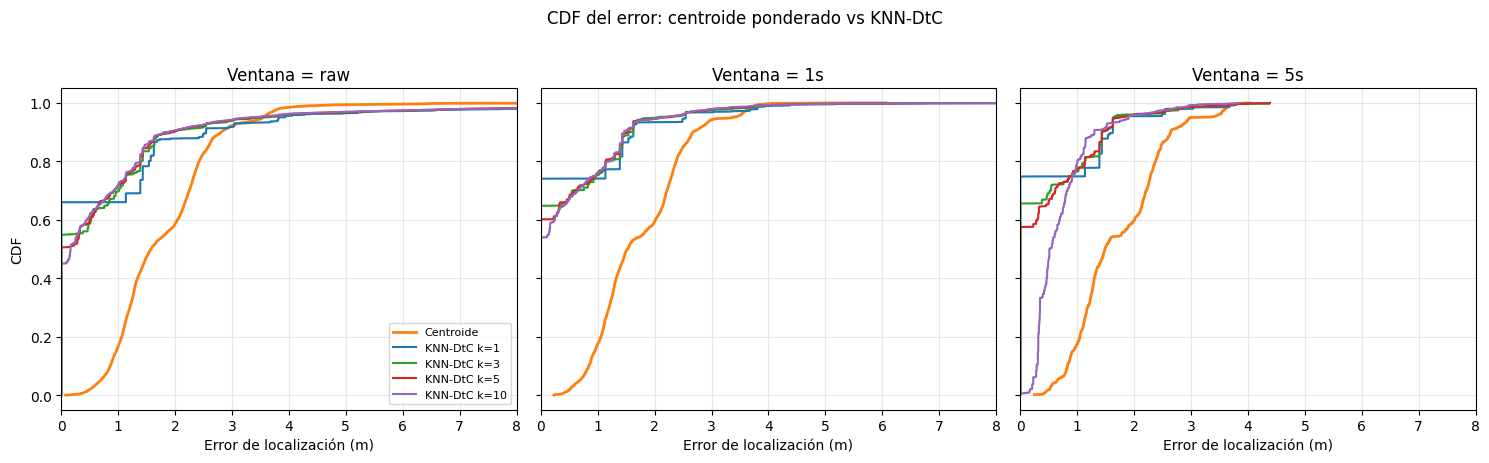

Saved figures: results/01_baselines_cdf.{png,pdf}


In [9]:
def plot_cdf(ax, errors, label, **kw):
    e = np.sort(np.asarray(errors))
    cdf = np.arange(1, len(e) + 1) / len(e)
    ax.plot(e, cdf, label=label, **kw)

fig, axes = plt.subplots(3, 1, figsize=(7.0, 9.6), sharex=True)
for ax, w in zip(axes, ['raw', '1s', '5s']):
    sub_c = df_centroid[df_centroid['window'] == w]
    plot_cdf(ax, sub_c['error'], 'Centroide', color='tab:orange', linewidth=2)
    for k, color in zip([1, 3, 5, 10], ['tab:blue', 'tab:green', 'tab:red', 'tab:purple']):
        sub_k = df_knn[(df_knn['window'] == w) & (df_knn['method'] == f'KNN-DtC-k{k}')]
        plot_cdf(ax, sub_k['error'], f'KNN-DtC k={k}', color=color, linewidth=1.5)
    ax.set_xlim(0, 8)
    ax.set_ylabel('CDF')
    ax.set_title(f'Ventana = {w}')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Error de localización (m)')
axes[0].legend(fontsize=9, loc='lower right')
fig.suptitle('CDF del error: centroide ponderado vs KNN-DtC', y=0.995)
fig.tight_layout()
fig.savefig(RESULTS / '01_baselines_cdf.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS / '01_baselines_cdf.pdf', bbox_inches='tight')
plt.show()
print('Saved figures: results/01_baselines_cdf.{png,pdf}')

## 5. Tabla compacta para el capítulo 4

Tabla resumen para insertar en `main_PEC4.tex`: error medio (m) por método y ventana, agregando todos los subsets evaluados.

In [10]:
compact_rows = []
for w in ['raw', '1s', '5s']:
    sub_c = df_centroid[df_centroid['window'] == w]
    compact_rows.append({
        'metodo': 'Centroide ponderado', 'ventana': w,
        'mean_m': float(sub_c['error'].mean()),
        'median_m': float(sub_c['error'].median()),
        'p95_m': float(np.percentile(sub_c['error'], 95)),
    })
    for k in [1, 3, 5, 10]:
        sub_k = df_knn[(df_knn['window'] == w) & (df_knn['method'] == f'KNN-DtC-k{k}')]
        compact_rows.append({
            'metodo': f'KNN-DtC k={k}', 'ventana': w,
            'mean_m': float(sub_k['error'].mean()),
            'median_m': float(sub_k['error'].median()),
            'p95_m': float(np.percentile(sub_k['error'], 95)),
        })
compact = pd.DataFrame(compact_rows).round(3)
compact.to_csv(RESULTS / '01_baselines_compact.csv', index=False)
print(compact.to_string(index=False))

             metodo ventana  mean_m  median_m  p95_m
Centroide ponderado     raw   1.801     1.576  3.545
        KNN-DtC k=1     raw   0.911     0.000  3.831
        KNN-DtC k=3     raw   0.863     0.000  3.538
        KNN-DtC k=5     raw   0.849     0.000  3.425
       KNN-DtC k=10     raw   0.843     0.163  3.293
Centroide ponderado      1s   1.741     1.523  3.366
        KNN-DtC k=1      1s   0.499     0.000  2.545
        KNN-DtC k=3      1s   0.513     0.000  2.026
        KNN-DtC k=5      1s   0.516     0.000  2.169
       KNN-DtC k=10      1s   0.526     0.000  2.153
Centroide ponderado      5s   1.721     1.488  2.980
        KNN-DtC k=1      5s   0.436     0.000  1.635
        KNN-DtC k=3      5s   0.460     0.000  1.635
        KNN-DtC k=5      5s   0.490     0.000  1.751
       KNN-DtC k=10      5s   0.727     0.518  1.898
